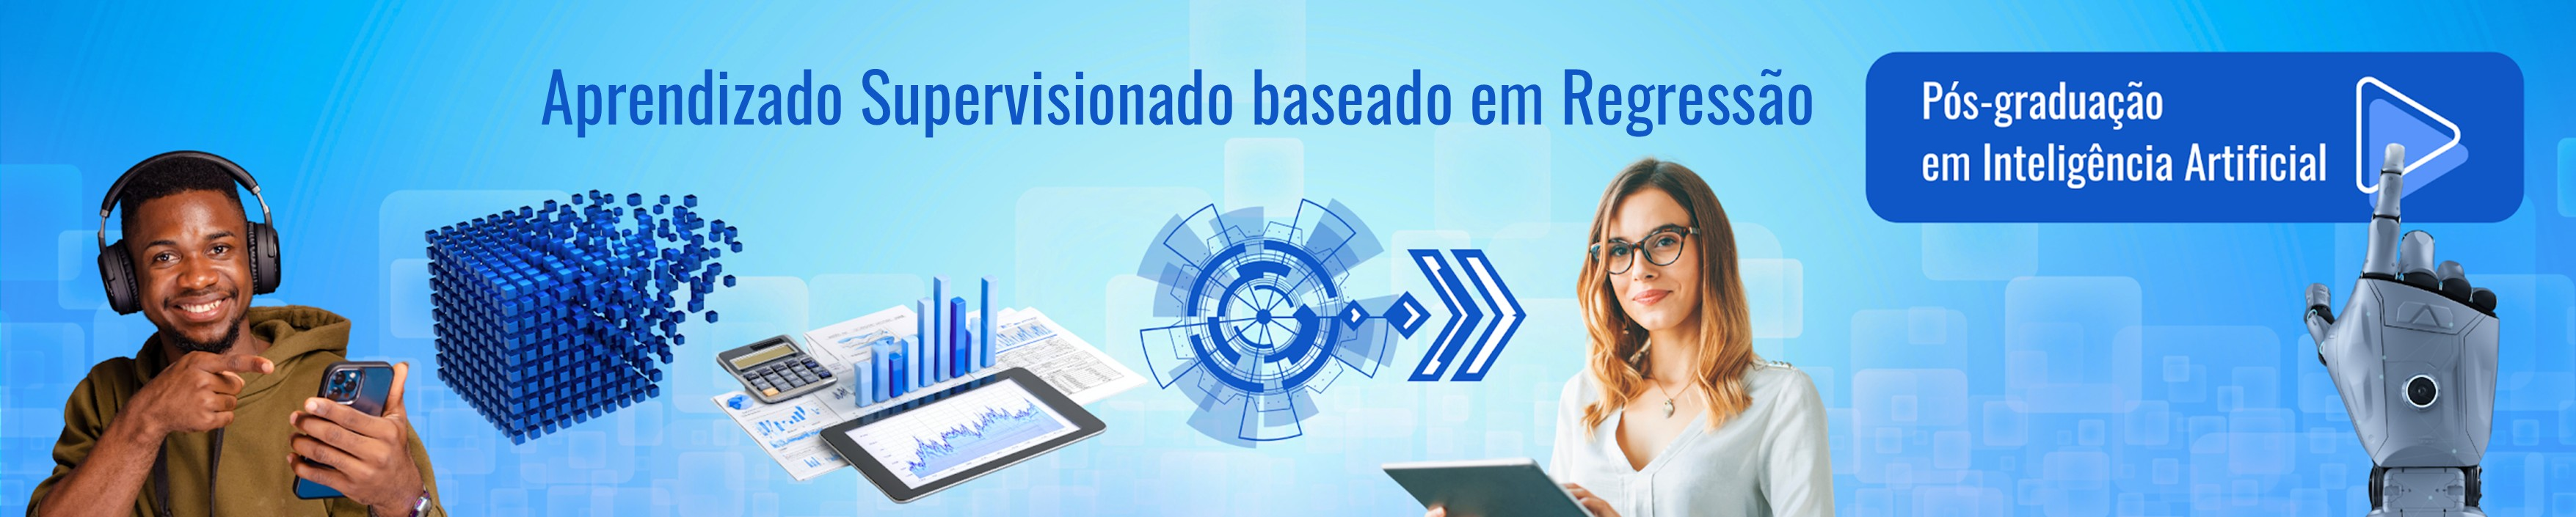

# 💻 Atividade Computacional 5: Previsão do Valor do Seguro com SVR

---

📊 **Valor total:** 10 pontos  
📅 **Data de entrega:** 21/09/2026 às 23h59  
📝 **Importante:** realize os códigos solicitados e, ao final de cada questão, responda à pergunta proposta.

## Contexto do problema

Uma empresa de seguros médicos deseja estimar o **valor provável de cobrança de um seguro** para um novo cliente. Essa previsão pode ajudar em análises de risco, simulações de preço e comparação entre perfis de clientes.

Nesta atividade, vamos usar o banco de dados **Insurance**, em que a variável-alvo é:

- `charges`: valor cobrado pelo seguro médico.

As variáveis de entrada são:

- `age`: idade;
- `sex`: sexo;
- `bmi`: índice de massa corporal;
- `children`: número de filhos/dependentes;
- `smoker`: indica se a pessoa fuma;
- `region`: região de residência.

Nesta versão da atividade, o modelo principal será o **SVR — Support Vector Regression**.


## Por que usar SVR?

O SVR pode capturar relações **não lineares** entre as variáveis e o valor do seguro, especialmente quando usamos o kernel RBF. Porém, ele exige mais cuidado no pré-processamento, principalmente com a **normalização das entradas**, pois o modelo trabalha com distâncias entre os dados.

---

## O que será praticado

Nesta atividade, você irá:

1. Revisar o carregamento e a divisão da base de dados em uma única célula, sem pontuação;
2. Separar variáveis numéricas e categóricas;
3. Codificar variáveis categóricas com `OneHotEncoder()`;
4. Normalizar variáveis numéricas com `StandardScaler()`;
5. Construir um `Pipeline` com `SVR()`;
6. Avaliar o modelo com MAE, RMSE e R²;
7. Realizar, como atividade extra, ajuste com `GridSearchCV()`, gráfico de dependência parcial e comparação com `TransformedTargetRegressor()`.

---

# 0. Bibliotecas utilizadas

Execute esta célula antes de iniciar a atividade.

Ela realiza apenas a importação das bibliotecas que serão usadas no notebook.

## Principais funções utilizadas

| Função/classe | Uso na atividade |
|---|---|
| `pd.read_csv()` | carregar o banco de dados |
| `train_test_split()` | separar treino e teste |
| `ColumnTransformer()` | aplicar transformações diferentes por tipo de variável |
| `OneHotEncoder()` | transformar variáveis categóricas em colunas numéricas |
| `StandardScaler()` | normalizar variáveis numéricas de entrada |
| `Pipeline()` | organizar pré-processamento e modelo |
| `SVR()` | modelo de regressão por vetores de suporte |
| `GridSearchCV()` | testar combinações de hiperparâmetros |
| `PartialDependenceDisplay.from_estimator()` | gerar gráfico de dependência parcial |
| `TransformedTargetRegressor()` | atividade extra: transformar a escala do alvo e comparar resultados |

> Na atividade principal, o `TransformedTargetRegressor()` **não será usado**. Ele aparece apenas na atividade extra de comparação.


In [1]:
# ============================================================
# CÉLULA 0 — BIBLIOTECAS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay

RANDOM_STATE = 42

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

---
# ✏️ Questão 1 — Revisão: carregar e dividir a base de dados em uma única célula `(sem pontuação)`

Nesta questão, vamos preparar a base de forma direta, sem realizar análise exploratória inicial.

> **Observação:** esta questão não será pontuada, pois essa etapa já foi trabalhada na Tarefa 3. Ela aparece aqui apenas para deixar o notebook completo e permitir que as demais questões sejam executadas.

## O que você deve fazer

Em uma única célula de código:

1. Carregue o dataset `insurance.csv`;
2. Crie `X` com as variáveis de entrada;
3. Crie `y` com a variável-alvo `charges`;
4. Separe os dados em treino e teste;
5. Crie as listas com variáveis numéricas e categóricas;
6. Mostre o tamanho dos conjuntos gerados.

## Funções utilizadas

```python
pd.read_csv()
df.drop()
train_test_split()
```

## Insight

Para treinar um modelo de Machine Learning, precisamos separar os dados em duas partes:

- **treino**: usado para ajustar o modelo;
- **teste**: usado para avaliar se o modelo generaliza para dados novos.

Nesta atividade, não faremos uma análise exploratória detalhada, pois o foco será o uso do **SVR com pré-processamento e normalização**.

In [2]:
# Código da Questão 1

# Escreva aqui a sua solução.

In [3]:
#@title ✅ Gabarito da Questão 1 — carregar e dividir a base { display-mode: "form" }

# ------------------------------------------------------------
# 1. Carregar o dataset Insurance
# ------------------------------------------------------------
url = "https://raw.githubusercontent.com/krish1407/Medical-Cost-Personal-Datasets/master/insurance.csv"
df = pd.read_csv(url)

# ------------------------------------------------------------
# 2. Separar entradas e alvo
# ------------------------------------------------------------
X = df.drop(columns=["charges"])
y = df["charges"]

# ------------------------------------------------------------
# 3. Definir as variáveis por tipo
# ------------------------------------------------------------
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

# ------------------------------------------------------------
# 4. Separar treino e teste
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# ------------------------------------------------------------
# 5. Conferir os resultados
# ------------------------------------------------------------
print("Tamanho da base completa:", df.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nVariáveis numéricas:", numeric_features)
print("Variáveis categóricas:", categorical_features)

print("\nPrimeiras linhas de X_train:")
display(X_train.head())

Tamanho da base completa: (1338, 7)
X_train: (1070, 6)
X_test: (268, 6)
y_train: (1070,)
y_test: (268,)

Variáveis numéricas: ['age', 'bmi', 'children']
Variáveis categóricas: ['sex', 'smoker', 'region']

Primeiras linhas de X_train:


,age,sex,bmi,children,smoker,region
560,46,female,19.95,2,no,northwest
1285,47,female,24.32,0,no,northeast
1142,52,female,24.86,0,no,southeast
969,39,female,34.32,5,no,southeast
486,54,female,21.47,3,no,northwest


---
# ✏️ Questão 2 — Pré-processamento das variáveis categóricas `(2,5 pontos)`

O SVR não consegue trabalhar diretamente com colunas de texto, como `sex`, `smoker` e `region`.

Por isso, precisamos transformar essas variáveis em números usando `OneHotEncoder()`.

## O que você deve fazer

1. Crie um transformador para as variáveis categóricas usando `OneHotEncoder()`;
2. Mantenha as variáveis numéricas sem normalização nesta questão;
3. Use `ColumnTransformer()` para organizar o pré-processamento;
4. Aplique o pré-processador em `X_train` apenas para visualizar o resultado transformado;
5. Mostre o número de colunas antes e depois do pré-processamento.

## Funções utilizadas

```python
OneHotEncoder()
ColumnTransformer()
fit_transform()
get_feature_names_out()
```

## Insight

O `OneHotEncoder()` cria colunas binárias. Por exemplo, a variável `smoker` pode gerar uma coluna indicando se a pessoa é fumante ou não.

Nesta questão, ainda **não vamos normalizar** as variáveis numéricas. A normalização será tratada separadamente na próxima questão, pois ela é um ponto essencial para o SVR.

In [4]:
# Código da Questão 2

# Escreva aqui a sua solução.

In [5]:
#@title ✅ Gabarito da Questão 2 — pré-processamento categórico { display-mode: "form" }

# ------------------------------------------------------------
# 1. Criar o OneHotEncoder
# ------------------------------------------------------------
codificador_categorico = OneHotEncoder(handle_unknown="ignore", sparse_output=False)


# ------------------------------------------------------------
# 2. Criar o pré-processador sem normalização
# ------------------------------------------------------------
preprocessador_sem_normalizacao = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", codificador_categorico, categorical_features)
    ],
    remainder="drop"
)

# ------------------------------------------------------------
# 3. Ajustar e transformar X_train
# ------------------------------------------------------------
X_train_transformado = preprocessador_sem_normalizacao.fit_transform(X_train)

# ------------------------------------------------------------
# 4. Recuperar nomes das colunas transformadas
# ------------------------------------------------------------
nomes_features_sem_norm = preprocessador_sem_normalizacao.get_feature_names_out()

print("Número de colunas originais:", X_train.shape[1])
print("Número de colunas após OneHotEncoder:", X_train_transformado.shape[1])

print("\nNomes das colunas após o pré-processamento:")
print(nomes_features_sem_norm)

print("\nAmostra dos dados transformados:")
display(pd.DataFrame(X_train_transformado, columns=nomes_features_sem_norm).head())

Número de colunas originais: 6
Número de colunas após OneHotEncoder: 11

Nomes das colunas após o pré-processamento:
['num__age' 'num__bmi' 'num__children' 'cat__sex_female' 'cat__sex_male'
 'cat__smoker_no' 'cat__smoker_yes' 'cat__region_northeast'
 'cat__region_northwest' 'cat__region_southeast' 'cat__region_southwest']

Amostra dos dados transformados:


,num__age,num__bmi,num__children,cat__sex_female,cat__sex_male,cat__smoker_no,cat__smoker_yes,cat__region_northeast,cat__region_northwest,cat__region_southeast,cat__region_southwest
0,46.0,19.95,2.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,47.0,24.32,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,52.0,24.86,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,39.0,34.32,5.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,54.0,21.47,3.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


## 🧠 Pergunta de múltipla escolha — Questão 2

Por que usamos `OneHotEncoder()` nas variáveis categóricas?

A. Para remover automaticamente as variáveis categóricas.  
B. Para transformar categorias de texto em colunas numéricas binárias.  
C. Para calcular diretamente o RMSE do modelo.  
D. Para substituir o SVR por regressão linear.

**Resposta**:

---
# ✏️ Questão 3 — Normalização para uso do SVR `(2,5 pontos)`

O SVR, principalmente com kernel RBF, depende de cálculos de distância entre os pontos. Por isso, variáveis em escalas diferentes podem prejudicar o modelo.

Nesta questão, vamos criar o pré-processamento adequado para o SVR.

## O que você deve fazer

1. Aplique `StandardScaler()` nas variáveis numéricas;
2. Aplique `OneHotEncoder()` nas variáveis categóricas;
3. Use `ColumnTransformer()` para combinar as duas transformações;
4. Explique por que a normalização é importante para o SVR.

## Funções utilizadas

```python
StandardScaler()
OneHotEncoder()
ColumnTransformer()
```

## Insight

Sem normalização, uma variável com valores maiores pode dominar o cálculo de distância.

Exemplo:

- `age` pode variar de 18 a 64;
- `bmi` pode variar aproximadamente de 15 a 50;
- `children` varia de 0 a 5.

O `StandardScaler()` coloca as variáveis numéricas em uma escala comparável, com média próxima de 0 e desvio padrão próximo de 1.

In [6]:
# Código da Questão 3

# Escreva aqui a sua solução.

In [7]:
#@title ✅ Gabarito da Questão 3 — normalização para SVR { display-mode: "form" }

# ------------------------------------------------------------
# 1. Criar o OneHotEncoder
# ------------------------------------------------------------
onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)


# ------------------------------------------------------------
# 2. Criar o pré-processador com normalização
# ------------------------------------------------------------
preprocessador_com_normalizacao = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", onehot, categorical_features)
    ],
    remainder="drop"
)

# ------------------------------------------------------------
# 3. Visualizar o efeito da transformação
# ------------------------------------------------------------
X_train_norm = preprocessador_com_normalizacao.fit_transform(X_train)
nomes_features_norm = preprocessador_com_normalizacao.get_feature_names_out()

print("Número de colunas após o pré-processamento:", X_train_norm.shape[1])
print("\nNomes das colunas:")
print(nomes_features_norm)

print("\nAmostra dos dados transformados:")
display(pd.DataFrame(X_train_norm, columns=nomes_features_norm).head())

print("\nInsight:")
print("No SVR com kernel RBF, a normalização é importante porque o modelo compara distâncias entre observações.")
print("Se as variáveis numéricas estiverem em escalas muito diferentes, uma delas pode dominar o cálculo do modelo.")

Número de colunas após o pré-processamento: 11

Nomes das colunas:
['num__age' 'num__bmi' 'num__children' 'cat__sex_female' 'cat__sex_male'
 'cat__smoker_no' 'cat__smoker_yes' 'cat__region_northeast'
 'cat__region_northwest' 'cat__region_southeast' 'cat__region_southwest']

Amostra dos dados transformados:


,num__age,num__bmi,num__children,cat__sex_female,cat__sex_male,cat__smoker_no,cat__smoker_yes,cat__region_northeast,cat__region_northwest,cat__region_southeast,cat__region_southwest
0,0.472227,-1.756525,0.734336,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.543313,-1.033082,-0.911192,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,0.898745,-0.943687,-0.911192,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-0.025379,0.622393,3.202629,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1.040918,-1.504893,1.557100,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0



Insight:
No SVR com kernel RBF, a normalização é importante porque o modelo compara distâncias entre observações.
Se as variáveis numéricas estiverem em escalas muito diferentes, uma delas pode dominar o cálculo do modelo.


## 🧠 Pergunta de múltipla escolha — Questão 3

Por que a normalização é especialmente importante no SVR com kernel RBF?

A. Porque o SVR só aceita valores entre 0 e 1.  
B. Porque o SVR com RBF depende de distâncias entre os pontos.  
C. Porque o `OneHotEncoder()` exige variáveis normalizadas.  
D. Porque o `train_test_split()` só funciona com dados normalizados.

**Resposta**:

---
# ✏️ Questão 4 — Montagem do modelo SVR com `Pipeline` `(2,5 pontos)`

Agora vamos montar o modelo completo usando `Pipeline()`.

Nesta questão, o modelo deve juntar:

1. o pré-processamento das entradas;
2. o modelo `SVR()`.


## O que você deve fazer

1. Crie um `Pipeline` com:
   - `preprocessador_com_normalizacao`;
   - `SVR(kernel="rbf")`;
2. Use os hiperparâmetros iniciais:
   - `C=100000`;
   - `epsilon=0.01`;
   - `gamma="scale"`;
3. Treine o modelo com `X_train` e `y_train`;
4. Faça previsões para treino e teste.

## Funções utilizadas

```python
Pipeline()
SVR()
fit()
predict()
```

## Insight

O `Pipeline()` evita vazamento de dados porque o pré-processamento é ajustado apenas no conjunto de treino e depois aplicado ao conjunto de teste.

No SVR, a normalização das entradas é muito importante. Porém, nesta primeira versão, manteremos `charges` na escala original para entender o comportamento básico do modelo.


In [8]:
# Código da Questão 4

# Escreva aqui a sua solução.

In [9]:
#@title ✅ Gabarito da Questão 4 — pipeline com SVR sem transformar o alvo { display-mode: "form" }

# ------------------------------------------------------------
# 1. Criar o pipeline do SVR
# ------------------------------------------------------------
modelo_svr = Pipeline(steps=[
    ("preprocessamento", preprocessador_com_normalizacao),
    ("modelo", SVR(kernel="rbf", C=100000, epsilon=0.01, gamma="scale"))
])

# ------------------------------------------------------------
# 2. Treinar o modelo
# ------------------------------------------------------------
modelo_svr.fit(X_train, y_train)

# ------------------------------------------------------------
# 3. Fazer previsões
# ------------------------------------------------------------
pred_train_svr = modelo_svr.predict(X_train)
pred_test_svr = modelo_svr.predict(X_test)

print("Modelo SVR treinado com sucesso.")
print("A variável-alvo charges foi mantida na escala original.")
print("Primeiras previsões no teste:")

display(pd.DataFrame({
    "valor_real": y_test.values[:10],
    "valor_previsto": pred_test_svr[:10]
}))

print("\nInsight:")
print("Neste modelo, apenas as entradas foram normalizadas.")
print("O alvo charges continua na escala original, por isso C e epsilon também estão relacionados a essa escala de valores.")


Modelo SVR treinado com sucesso.
A variável-alvo charges foi mantida na escala original.
Primeiras previsões no teste:


,valor_real,valor_previsto
0,9095.06825,9107.864681
1,5272.17580,5265.680864
2,29330.98315,29115.219443
3,9301.89355,9447.502254
4,33750.29180,24617.405838
5,4536.25900,4460.267407
6,2117.33885,2122.238291
7,14210.53595,14178.614071
8,3732.62510,3661.998506
9,10264.44210,10287.967756



Insight:
Neste modelo, apenas as entradas foram normalizadas.
O alvo charges continua na escala original, por isso C e epsilon também estão relacionados a essa escala de valores.


## 🧠 Pergunta de múltipla escolha — Questão 4

Na atividade principal, qual transformação está sendo aplicada antes do `SVR()`?

A. Apenas a normalização da variável-alvo `charges`.  
B. A codificação das categóricas e a normalização das variáveis numéricas de entrada.  
C. A remoção de todas as variáveis categóricas.  
D. A transformação de `charges` em variável categórica.


**Resposta**:

---
# ✏️ Questão 5 — Métricas de desempenho do SVR `(2,5 pontos)`

Depois de treinar o modelo, precisamos avaliar seu desempenho.

## O que você deve fazer

1. Calcule o MAE no treino e no teste;
2. Calcule o RMSE no treino e no teste;
3. Calcule o R² no treino e no teste;
4. Monte uma tabela com os resultados;
5. Faça um gráfico de valores reais versus valores previstos no teste;
6. Escreva um insight sobre o desempenho do SVR.

## Funções utilizadas

```python
mean_absolute_error()
mean_squared_error()
r2_score()
plt.scatter()
```

## Insight

- **MAE** mede o erro médio absoluto;
- **RMSE** penaliza mais erros grandes;
- **R²** indica quanto da variação do alvo foi explicada pelo modelo.

Um bom modelo deve ter erro baixo no teste e desempenho semelhante entre treino e teste.

In [10]:
# Código da Questão 5

# Escreva aqui a sua solução.

,Modelo,MAE treino,MAE teste,RMSE treino,RMSE teste,R² treino,R² teste
0,SVR RBF,1529.316882,1694.18585,4602.365951,4548.700026,0.853244,0.866726


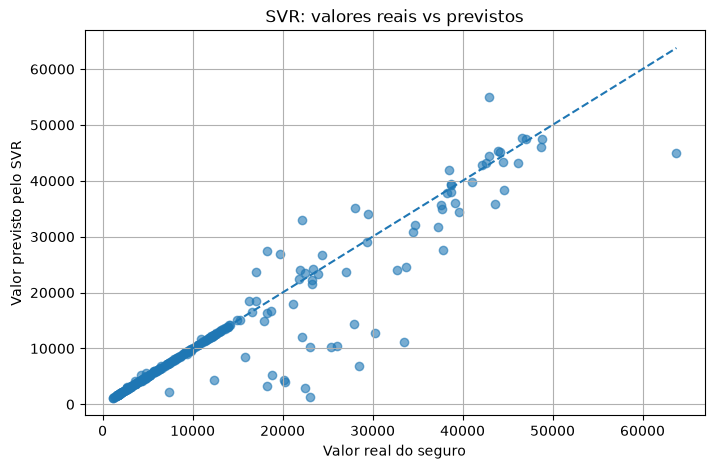

Insight:
Compare treino e teste. Se o erro de teste for muito maior que o erro de treino, pode haver overfitting.
Se ambos os erros forem altos, o modelo pode estar subajustado ou precisar de ajuste de hiperparâmetros.


In [11]:
#@title ✅ Gabarito da Questão 5 — métricas do SVR { display-mode: "form" }

# ------------------------------------------------------------
# 1. Calcular métricas
# ------------------------------------------------------------
mae_train = mean_absolute_error(y_train, pred_train_svr)
mae_test = mean_absolute_error(y_test, pred_test_svr)

rmse_train = mean_squared_error(y_train, pred_train_svr) ** 0.5
rmse_test = mean_squared_error(y_test, pred_test_svr) ** 0.5

r2_train = r2_score(y_train, pred_train_svr)
r2_test = r2_score(y_test, pred_test_svr)

# ------------------------------------------------------------
# 2. Montar tabela de resultados
# ------------------------------------------------------------
resultados_svr = pd.DataFrame({
    "Modelo": ["SVR RBF"],
    "MAE treino": [mae_train],
    "MAE teste": [mae_test],
    "RMSE treino": [rmse_train],
    "RMSE teste": [rmse_test],
    "R² treino": [r2_train],
    "R² teste": [r2_test]
})

display(resultados_svr)

# ------------------------------------------------------------
# 3. Gráfico: valores reais vs previstos
# ------------------------------------------------------------
plt.figure()
plt.scatter(y_test, pred_test_svr, alpha=0.6)

min_val = min(y_test.min(), pred_test_svr.min())
max_val = max(y_test.max(), pred_test_svr.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Valor real do seguro")
plt.ylabel("Valor previsto pelo SVR")
plt.title("SVR: valores reais vs previstos")
plt.show()

# ------------------------------------------------------------
# 4. Insight
# ------------------------------------------------------------
print("Insight:")
print("Compare treino e teste. Se o erro de teste for muito maior que o erro de treino, pode haver overfitting.")
print("Se ambos os erros forem altos, o modelo pode estar subajustado ou precisar de ajuste de hiperparâmetros.")

## 🧠 Pergunta de múltipla escolha — Questão 5

Qual métrica penaliza mais fortemente erros grandes?

A. MAE  
B. RMSE  
C. Quantidade de linhas  
D. Número de variáveis categóricas

**Resposta**:

---
# ⭐ Atividade Extra A — Ajuste de hiperparâmetros com `GridSearchCV()`

Esta atividade é complementar e serve para melhorar o desempenho do SVR testando várias combinações de hiperparâmetros.

## O que você deve fazer

1. Defina uma grade de valores para:
   - `C`;
   - `epsilon`;
   - `gamma`;
2. Use `GridSearchCV()` com validação cruzada;
3. Treine a busca usando `X_train` e `y_train`;
4. Mostre os melhores parâmetros;
5. Avalie o melhor modelo no conjunto de teste;
6. Compare com o SVR da atividade principal.

## Funções utilizadas

```python
GridSearchCV()
KFold()
best_params_
best_estimator_
```

## Insight

O SVR é sensível aos hiperparâmetros. O `GridSearchCV()` permite testar várias combinações de forma organizada e escolher aquela que apresenta melhor desempenho médio na validação cruzada.

In [12]:
# Código da Atividade Extra A

# Escreva aqui a sua solução.

Fitting 3 folds for each of 80 candidates, totalling 240 fits
Melhores parâmetros encontrados:
{'modelo__C': 10000, 'modelo__epsilon': 0.5, 'modelo__gamma': 0.1}

Melhor RMSE médio na validação cruzada:
5007.961314817883


,Modelo,MAE teste,RMSE teste,R² teste
0,SVR base,1694.185850,4548.700026,0.866726
1,SVR com GridSearchCV,1813.628717,4765.134608,0.853741


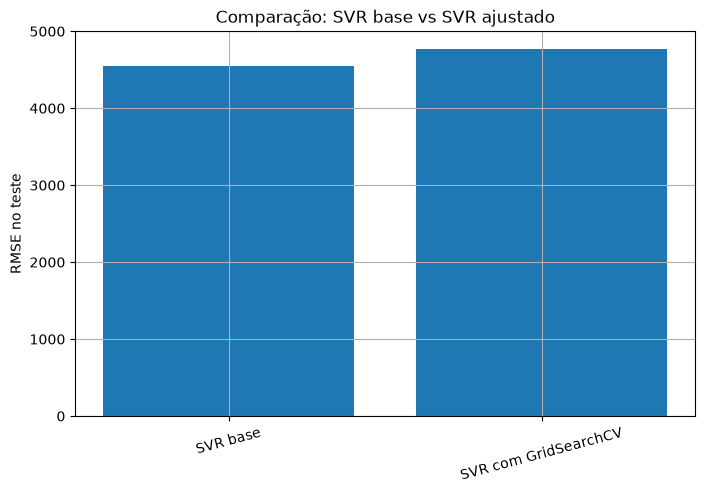


Insight:
Se o RMSE do SVR ajustado for menor e o R² for maior, o GridSearchCV melhorou o modelo.
Caso contrário, a grade testada pode não ter sido adequada ou o SVR base já estava próximo de um bom ajuste.


In [13]:
#@title ✅ Gabarito da Atividade Extra A — GridSearchCV no SVR { display-mode: "form" }

# ------------------------------------------------------------
# 1. Definir a grade de hiperparâmetros
# ------------------------------------------------------------
param_grid = {
    "modelo__C": [1, 10, 100, 1000,10000],
    "modelo__epsilon": [0.05, 0.1, 0.2, 0.5],
    "modelo__gamma": ["scale", 0.01, 0.05, 0.1]
}

# ------------------------------------------------------------
# 2. Definir validação cruzada
# ------------------------------------------------------------
cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

# ------------------------------------------------------------
# 3. Criar o GridSearchCV
# ------------------------------------------------------------
busca_svr = GridSearchCV(
    estimator=modelo_svr,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# ------------------------------------------------------------
# 4. Treinar a busca
# ------------------------------------------------------------
busca_svr.fit(X_train, y_train)

print("Melhores parâmetros encontrados:")
print(busca_svr.best_params_)

print("\nMelhor RMSE médio na validação cruzada:")
print(-busca_svr.best_score_)

# ------------------------------------------------------------
# 5. Avaliar o melhor modelo no teste
# ------------------------------------------------------------
modelo_svr_ajustado = busca_svr.best_estimator_

pred_test_svr_ajustado = modelo_svr_ajustado.predict(X_test)

mae_test_ajustado = mean_absolute_error(y_test, pred_test_svr_ajustado)
rmse_test_ajustado = mean_squared_error(y_test, pred_test_svr_ajustado) ** 0.5
r2_test_ajustado = r2_score(y_test, pred_test_svr_ajustado)

comparacao_grid = pd.DataFrame({
    "Modelo": ["SVR base", "SVR com GridSearchCV"],
    "MAE teste": [mae_test, mae_test_ajustado],
    "RMSE teste": [rmse_test, rmse_test_ajustado],
    "R² teste": [r2_test, r2_test_ajustado]
})

display(comparacao_grid)

plt.figure()
plt.bar(comparacao_grid["Modelo"], comparacao_grid["RMSE teste"])
plt.ylabel("RMSE no teste")
plt.title("Comparação: SVR base vs SVR ajustado")
plt.xticks(rotation=15)
plt.show()

print("\nInsight:")
print("Se o RMSE do SVR ajustado for menor e o R² for maior, o GridSearchCV melhorou o modelo.")
print("Caso contrário, a grade testada pode não ter sido adequada ou o SVR base já estava próximo de um bom ajuste.")


---
# ⭐ Atividade Extra B — Gráfico de dependência parcial com `PartialDependenceDisplay`

O SVR com kernel RBF não possui coeficientes simples como a regressão linear. Por isso, uma forma de interpretar o modelo é observar como a previsão muda quando alteramos uma variável de entrada.

Nesta atividade extra, vamos usar o gráfico de dependência parcial.

## O que você deve fazer

1. Escolha uma ou duas variáveis numéricas, como `age` e `bmi`;
2. Use `PartialDependenceDisplay.from_estimator()`;
3. Gere os gráficos de dependência parcial;
4. Escreva um insight sobre o comportamento da previsão.

## Funções utilizadas

```python
PartialDependenceDisplay.from_estimator()
plt.show()
```

## Insight

O gráfico de dependência parcial mostra a tendência média da previsão quando uma variável muda, mantendo o efeito das demais variáveis controlado de forma aproximada.

No caso do seguro, é interessante verificar se a previsão tende a aumentar com `age` ou `bmi`.

In [14]:
# Código da Atividade Extra B

# Escreva aqui a sua solução.

In [15]:
#@title ✅ Gabarito da Atividade Extra B — gráfico de dependência parcial { display-mode: "form" }

# ------------------------------------------------------------
# 1. Escolher o modelo para interpretação
# ------------------------------------------------------------
# Se a atividade de GridSearchCV já foi executada, usamos o modelo ajustado.
# Caso contrário, usamos o SVR base treinado na atividade principal.

if "modelo_svr_ajustado" in globals():
    modelo_para_pdp = modelo_svr_ajustado
    nome_modelo_pdp = "SVR ajustado com GridSearchCV"
else:
    modelo_para_pdp = modelo_svr
    nome_modelo_pdp = "SVR base"

print("Modelo usado no gráfico de dependência parcial:", nome_modelo_pdp)

# ------------------------------------------------------------
# 2. Plotar dependência parcial
# ------------------------------------------------------------
features_para_plotar = ["age", "bmi"]

PartialDependenceDisplay.from_estimator(
    modelo_para_pdp,
    X_test,
    features=features_para_plotar,
    kind="average"
)

plt.suptitle("Dependência parcial — previsão do valor do seguro", y=1.05)
plt.show()

print("\nInsight:")
print("Observe se a previsão média do seguro aumenta ou diminui quando age e bmi variam.")
print("Como o SVR com RBF é não linear, a curva pode não ser uma reta.")

Modelo usado no gráfico de dependência parcial: SVR ajustado com GridSearchCV


ValueError: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical features to floating point dtypes ahead of time to avoid problems.

---
# ⭐ Atividade Extra C — Comparação com `TransformedTargetRegressor()`

Nesta atividade extra, vamos estudar uma variação importante do SVR: transformar também a escala da variável-alvo `charges`.

## Por que isso pode ser útil?

O SVR é sensível à escala dos dados. Na atividade principal, normalizamos apenas as variáveis de entrada. Porém, a variável `charges` possui valores altos e muito espalhados.

Os hiperparâmetros do SVR, principalmente `C` e `epsilon`, dependem da escala do alvo. Por isso, em alguns problemas, transformar o alvo pode melhorar o ajuste.

## O que faz o `TransformedTargetRegressor()`?

O `TransformedTargetRegressor()` aplica uma transformação em `y` durante o treinamento e desfaz essa transformação automaticamente na previsão.

Nesta atividade, ele será usado com:

```python
TransformedTargetRegressor()
StandardScaler()
```

## O que você deve fazer

1. Crie um novo pipeline com o mesmo pré-processamento e o mesmo `SVR()` da atividade principal;
2. Envolva esse pipeline com `TransformedTargetRegressor()`;
3. Use `StandardScaler()` para transformar o alvo `charges`;
4. Treine o modelo;
5. Faça previsões no conjunto de teste;
6. Compare MAE, RMSE e R² com o SVR principal;
7. Escreva um insight dizendo se transformar o alvo melhorou ou não o desempenho.

## Funções utilizadas

```python
Pipeline()
SVR()
TransformedTargetRegressor()
StandardScaler()
fit()
predict()
mean_absolute_error()
mean_squared_error()
r2_score()
```

## Insight

A transformação do alvo não muda as variáveis de entrada. Ela muda apenas a escala temporária em que o modelo aprende a prever `charges`.

Depois da previsão, o `TransformedTargetRegressor()` retorna os valores novamente na unidade original do seguro.


In [ ]:
# Código da Atividade Extra C

# Escreva aqui a sua solução.

In [ ]:
#@title ✅ Gabarito da Atividade Extra C — SVR com TransformedTargetRegressor { display-mode: "form" }

# ------------------------------------------------------------
# 1. Criar um novo pipeline SVR igual ao da atividade principal
# ------------------------------------------------------------
svr_pipeline_para_alvo = Pipeline(steps=[
    ("preprocessamento", preprocessador_com_normalizacao),
    ("modelo", SVR(kernel="rbf", C=10, epsilon=0.1, gamma="scale"))
])

# ------------------------------------------------------------
# 2. Envolver o pipeline com TransformedTargetRegressor
# ------------------------------------------------------------
modelo_svr_com_alvo_transformado = TransformedTargetRegressor(
    regressor=svr_pipeline_para_alvo,
    transformer=StandardScaler()
)

# ------------------------------------------------------------
# 3. Treinar o modelo
# ------------------------------------------------------------
modelo_svr_com_alvo_transformado.fit(X_train, y_train)

# ------------------------------------------------------------
# 4. Fazer previsões
# ------------------------------------------------------------
pred_test_svr_alvo_transformado = modelo_svr_com_alvo_transformado.predict(X_test)

# ------------------------------------------------------------
# 5. Calcular métricas
# ------------------------------------------------------------
mae_test_alvo_transformado = mean_absolute_error(y_test, pred_test_svr_alvo_transformado)
rmse_test_alvo_transformado = mean_squared_error(y_test, pred_test_svr_alvo_transformado) ** 0.5
r2_test_alvo_transformado = r2_score(y_test, pred_test_svr_alvo_transformado)

# ------------------------------------------------------------
# 6. Comparar com o SVR principal
# ------------------------------------------------------------
comparacao_alvo = pd.DataFrame({
    "Modelo": [
        "SVR sem transformar charges",
        "SVR com TransformedTargetRegressor"
    ],
    "MAE teste": [
        mae_test,
        mae_test_alvo_transformado
    ],
    "RMSE teste": [
        rmse_test,
        rmse_test_alvo_transformado
    ],
    "R² teste": [
        r2_test,
        r2_test_alvo_transformado
    ]
})

display(comparacao_alvo)

# ------------------------------------------------------------
# 7. Gráfico comparativo
# ------------------------------------------------------------
plt.figure()
plt.bar(comparacao_alvo["Modelo"], comparacao_alvo["RMSE teste"])
plt.ylabel("RMSE no teste")
plt.title("Comparação: SVR com e sem transformação do alvo")
plt.xticks(rotation=15)
plt.show()

# ------------------------------------------------------------
# 8. Insight automático
# ------------------------------------------------------------
print("Insight:")

if rmse_test_alvo_transformado < rmse_test:
    print("Neste teste, transformar o alvo reduziu o RMSE no conjunto de teste.")
    print("Isso indica que o SVR pode ter se beneficiado de aprender o alvo charges em uma escala padronizada.")
elif rmse_test_alvo_transformado > rmse_test:
    print("Neste teste, transformar o alvo aumentou o RMSE no conjunto de teste.")
    print("Isso indica que, com estes hiperparâmetros, a transformação do alvo não melhorou o desempenho.")
else:
    print("Neste teste, os dois modelos apresentaram RMSE muito semelhante.")

print("\nObservação:")
print("Mesmo usando StandardScaler no alvo, as previsões retornam para a escala original de charges.")
